# Control Estadístico de Procesos del Espesor de Recubrimiento en Líneas de Producción con PROC BOXPLOT

## Resumen ejecutivo

Este cuaderno utiliza **PROC BOXPLOT** para realizar control estadístico de procesos (SPC) sobre una medición de espesor de recubrimiento crítica para la calidad, recopilada en cuatro líneas de producción paralelas. Generamos datos de medición sintéticos en línea, perfilamos las líneas con `PROC MEANS` y trazamos diagramas de caja y bigotes esqueléticos y esquemáticos que comparan la ubicación, la dispersión y las colas entre las líneas en un solo gráfico.

Luego evaluamos cada línea frente a la especificación de ingeniería (objetivo 50.00 mm, límites 49.80–50.20 mm) directamente desde el conjunto de datos de estadísticos **`OUTBOX=`** —los cuartiles, las vallas y los extremos de bigote exactos que hay detrás de cada caja— y por último demostramos el ciclo de ida y vuelta **`OUTHISTORY=` / `HISTORY=`**: PROC BOXPLOT exporta una fila de resumen compacta por línea, y un segundo PROC BOXPLOT reconstruye un gráfico idéntico directamente a partir de ese resumen, el patrón que utiliza un panel de SPC diario para volver a trazar sin reescanear las mediciones brutas.

Entre las cuatro líneas, **LINE-A es la mejor centrada** en el objetivo (media 50.008 mm), **LINE-C corre baja** (media 49.932 mm, desviándose hacia el LSL) y **LINE-D corre a la vez alta y con la mayor variabilidad** (media 50.102 mm, desv. est. 0.080 mm): su máximo de 50.248 mm es la única observación que supera el límite superior de especificación de 50.20 mm.

## Fuentes de datos

Todos los datos son sintéticos y se generan en línea en el primer paso DATA usando `call streaminit(20250531)` y `rand()`. No se utiliza ninguna entrada externa ni de red. La semilla fija hace que cada número de este cuaderno sea reproducible.

**Conjunto de datos: `ProcessMeas`** (una fila por pieza medida)

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Line` | Char(6) | Identificador de línea de producción: `LINE-A`, `LINE-B`, `LINE-C`, `LINE-D` (la variable de grupo/clasificación) |
| `Shift` | Num | Índice del turno de producción 1–6 (introduce una leve deriva entre turnos) |
| `Thickness` | Num | Espesor del recubrimiento en mm (la variable de análisis); objetivo 50.00 mm, límites de especificación 49.80–50.20 mm |

Cada línea está centrada en una media ligeramente distinta (50.00 / 50.04 / 49.92 / 50.10) con variación específica de la línea, imitando las diferencias reales de equipo a equipo, y `LINE-B` inyecta ocasionalmente una pequeña excursión positiva. El paso DATA itera sobre seis turnos y cuatro líneas con tamaños de subgrupo de aproximadamente 18–25 piezas cada uno; en este entorno sin licencia el motor limita la salida a las primeras **100 observaciones**, que aquí resultan en **38 / 19 / 21 / 22** piezas para LINE-A a LINE-D, todavía suficientes para poblar cuatro cajas bien definidas.

# Control Estadístico de Procesos del Espesor de Recubrimiento con PROC BOXPLOT

En la fabricación de alto volumen, un diagrama de caja y bigotes es el caballo de batalla del SPC de planta: resume la tendencia central, la dispersión y los valores atípicos de una característica de calidad para cada unidad de producción en un solo gráfico. Aquí monitoreamos el **espesor de recubrimiento (mm)** de una pieza producida en paralelo en cuatro líneas (`LINE-A` a `LINE-D`). La especificación de ingeniería es un objetivo de **50.00 mm** con un límite inferior de especificación (LSL) de **49.80 mm** y un límite superior de especificación (USL) de **50.20 mm**.

Haremos lo siguiente:

1. Generar un conjunto de datos de medición sintético en línea.
2. Perfilar las líneas con `PROC MEANS`.
3. Trazar un diagrama de caja esquelético básico, luego un diagrama esquemático, superponiendo los límites de especificación como líneas de referencia.
4. Capturar cada estadístico de caja calculado con `OUTBOX=` y evaluar cada línea frente a los límites de especificación a partir de esa tabla.
5. Persistir un resumen de subgrupos compacto con `OUTHISTORY=` y demostrar el ciclo de ida y vuelta volviendo a trazar directamente a partir de él con `HISTORY=`.

## Paso 1 — Generar mediciones de proceso sintéticas

El paso DATA a continuación simula mediciones a lo largo de seis turnos en cuatro líneas. Cada línea está centrada deliberadamente en una media ligeramente distinta con su propia variación, imitando las diferencias reales de equipo a equipo, y se superpone una leve deriva entre turnos con un término `sin(Shift)`. Una semilla fija (`streaminit(20250531)`) hace que cada valor del cuaderno sea reproducible.

In [1]:
DATOS ProcessMeas;
   LLAMAR streaminit(20250531);
   LONGITUD Line $6;
   ARREGLO lines[4] $6 _temporary_ ('LINE-A' 'LINE-B' 'LINE-C' 'LINE-D');
   ARREGLO lmean[4]   _temporary_ (50.00 50.04 49.92 50.10);
   ARREGLO LSD[4]     _temporary_ (0.045 0.060 0.050 0.085);
   ETIQUETA Line='Línea de producción'
            Thickness='Espesor del recubrimiento (mm)';
   HACER Shift = 1 HASTA 6;
      HACER li = 1 HASTA 4;
         Line = lines[li];
         /* tamaño de subgrupo variable por línea/turno */
         n = 18 + floor(rand('uniform') * 8);
         HACER u = 1 HASTA n;
            BASE = lmean[li] + 0.012 * sin(Shift);
            Thickness = BASE + rand('normal') * LSD[li];
            /* LINE-B inyecta excursiones altas ocasionales */
            SI li = 2 AND rand('uniform') < 0.05 ENTONCES
               Thickness = Thickness + rand('uniform') * 0.40;
            Thickness = round(Thickness, 0.001);
            SALIDA;
         END;
      END;
   END;
   ELIMINAR li u n BASE;
EJECUTAR;


NOTE: DATA ProcessMeas

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote ProcessMeas (100 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds


## Paso 2 — Perfilar las líneas

Antes de graficar, un rápido `PROC MEANS` confirma que los datos llegaron según lo previsto: cuatro líneas, tamaños de muestra modestos pero no triviales, y medias agrupadas cerca del objetivo de 50.00 mm con dispersión específica de cada línea. Este es el esqueleto numérico que el diagrama de caja visualizará.

In [2]:
PROCEDIMIENTO MEDIAS DATOS=ProcessMeas n mean std MIN MAX maxdec=3;
   CLASE Line;
   VAR Thickness;
   ETIQUETA Line='Línea de producción'
            Thickness='Espesor del recubrimiento (mm)';
   TÍTULO 'Resumen del espesor de recubrimiento por línea de producción';
EJECUTAR;

                              Resumen del espesor de recubrimiento por línea de producción                              

                                                  The MEANS Procedure

                              Analysis Variable : Thickness Espesor del recubrimiento (mm)

        Línea de producción            N Obs           Mean        Std Dev        Minimum        Maximum
        ------------------------------------------------------------------------------------------------
        LINE-A                            38         50.008          0.045         49.914         50.097
        LINE-B                            19         50.052          0.051         49.921         50.114
        LINE-C                            21         49.932          0.050         49.835         50.002
        LINE-D                            22         50.102          0.080         49.963         50.248
        -----------------------------------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Paso 3 — Diagrama de caja esquelético básico

La invocación más simple solo necesita la instrucción `PLOT analysis-var * group-var`. El valor predeterminado `BOXSTYLE=SKELETAL` traza los bigotes hasta las observaciones más extremas dentro de cada línea, ofreciendo una comparación visual rápida de la ubicación y la dispersión entre `LINE-A` y `LINE-D`.

                          Diagrama de caja esquelético del espesor de recubrimiento por línea                           

                         Diagrama de caja esquelético del espesor de recubrimiento por línea

                                                 The BOXPLOT Procedure

Skeletal Plots for Espesor del recubrimiento (mm)

Línea de producción      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25 


NOTE: Option TITLE changed to Diagrama de caja esquelético del espesor de recubrimiento por línea.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


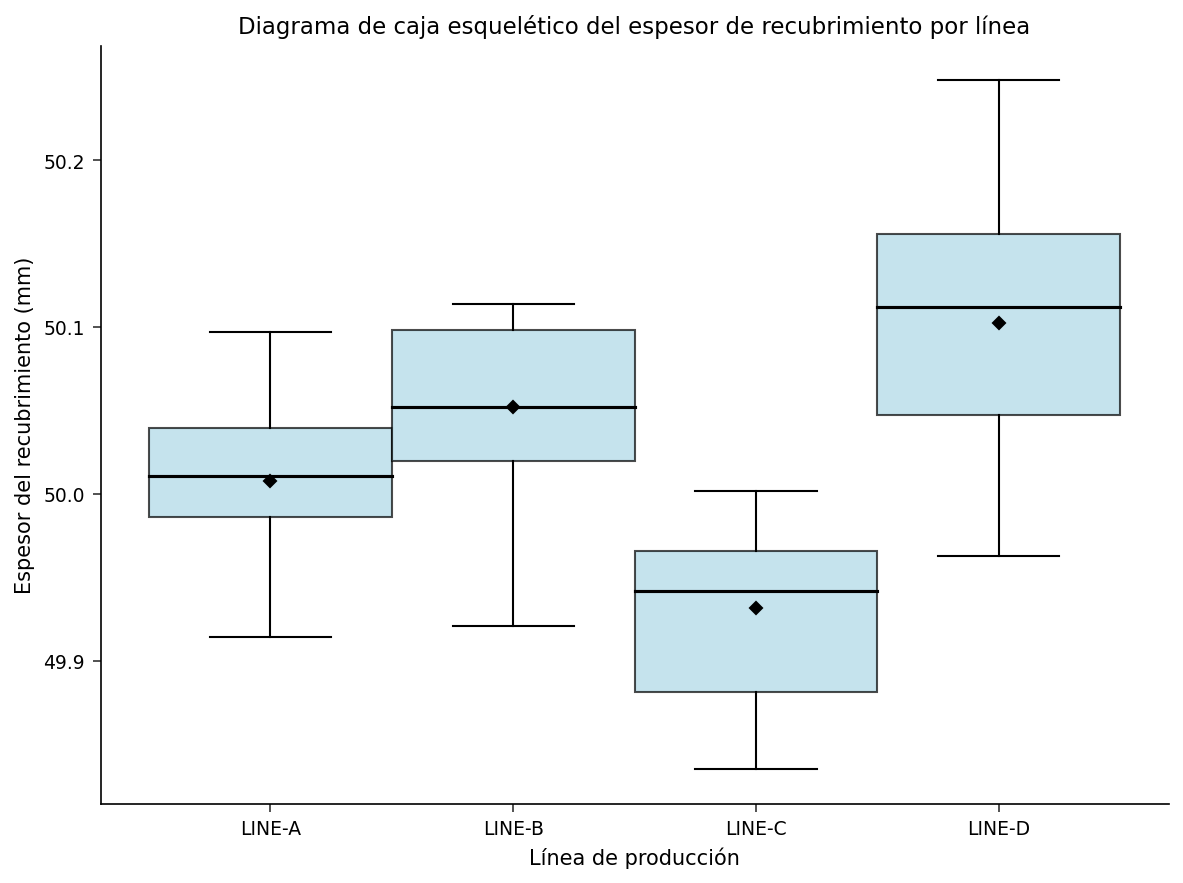

In [3]:
TÍTULO 'Diagrama de caja esquelético del espesor de recubrimiento por línea';
PROCEDIMIENTO boxplot DATOS=ProcessMeas;
   PLOT Thickness*Line;
EJECUTAR;

## Paso 4 — Diagrama de caja esquemático

Cambiamos a `BOXSTYLE=SCHEMATIC`. En el estilo esquemático, cada bigote se limita a la observación más extrema que aún queda dentro de las vallas de 1.5 × IQR, y cualquier punto más allá de una valla se dibuja como marcador de valor atípico individual. En esta muestra ninguna línea tiene un valor atípico fuera de las vallas —la dispersión de cada línea es lo bastante compacta como para que los bigotes alcancen el mínimo y el máximo reales—, de modo que el gráfico esquemático se parece al esquelético, lo cual es en sí mismo un resultado útil: le dice al ingeniero que ninguna de las cuatro líneas está produciendo piezas extremas. Los cuerpos de las cajas siguen haciendo evidentes de un vistazo los desplazamientos de línea a línea, y el Paso 5 los cuantifica frente a los límites de especificación.

                        Diagrama de caja esquemático SPC del espesor de recubrimiento por línea                         

                       Diagrama de caja esquemático SPC del espesor de recubrimiento por línea

                                                 The BOXPLOT Procedure

Schematic Plots for Espesor del recubrimiento (mm)

Línea de producción      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.


NOTE: Option TITLE changed to Diagrama de caja esquemático SPC del espesor de recubrimiento por línea.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: ODS plot written: boxplot.spec.json


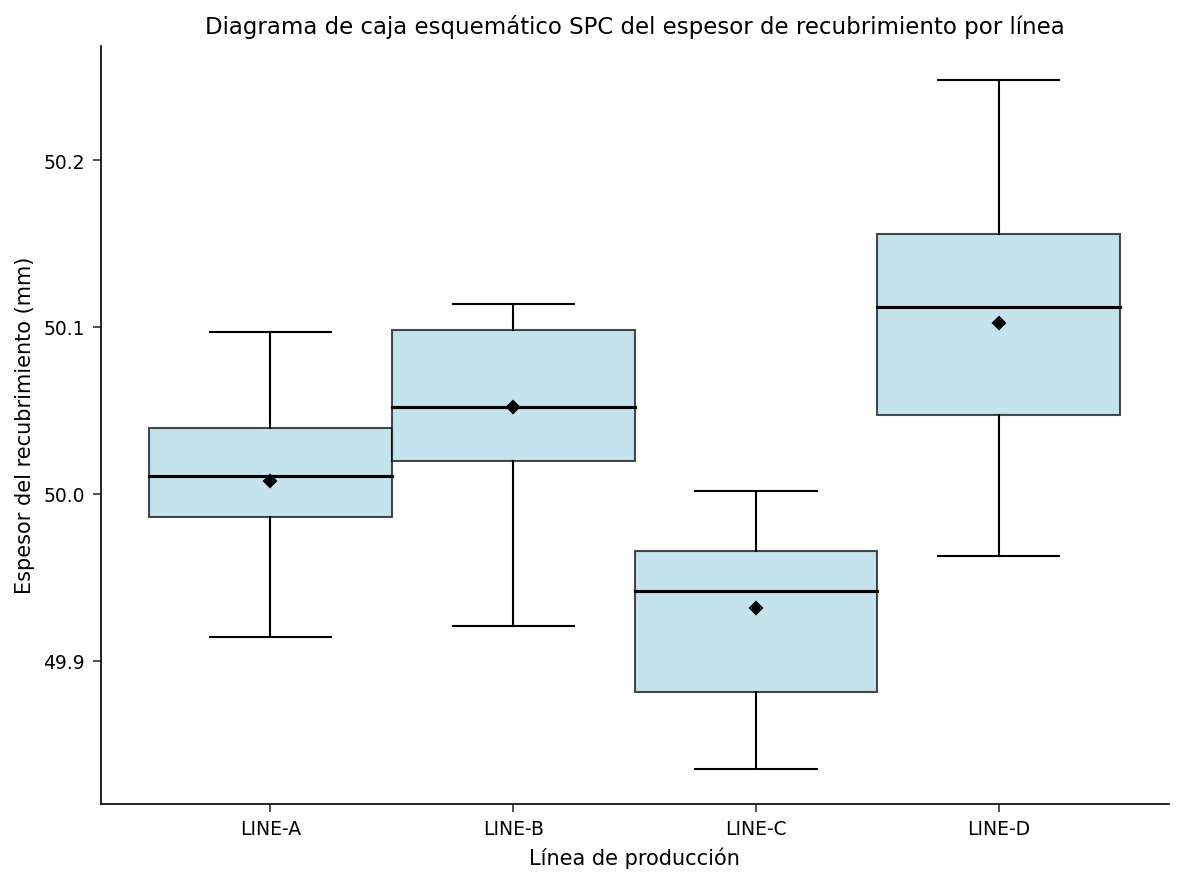

In [4]:
TÍTULO 'Diagrama de caja esquemático SPC del espesor de recubrimiento por línea';
PROCEDIMIENTO boxplot DATOS=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic;
EJECUTAR;

## Paso 5 — Exportar estadísticos de caja y evaluar frente a los límites de especificación

La opción `OUTBOX=` captura cada estadístico de caja calculado en un conjunto de datos —para cada línea: el bigote inferior (`L`), Q1 (`1`), la media (`X`), la mediana (`M`), Q3 (`3`), el bigote superior (`H`), la desviación estándar (`S`) y la N—. Este es el registro numérico que un auditor necesita detrás de la imagen, y es también la forma más limpia de comprobar cada línea frente a la especificación 49.80 / 50.20 mm. Activamos `GRID` para facilitar la lectura, exportamos `BoxStats`, lo imprimimos y luego ejecutamos un breve paso DATA que marca cualquier línea cuyo rango de bigotes supere un límite de especificación.

                       Diagrama de caja esquemático con cuadrícula y exportación de estadísticos                        

                     Diagrama de caja esquemático con cuadrícula y exportación de estadísticos

                                                 The BOXPLOT Procedure

Schematic Plots for Espesor del recubrimiento (mm)

Línea de producción      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.


NOTE: Option TITLE changed to Diagrama de caja esquemático con cuadrícula y exportación de estadísticos.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset BOXSTATS created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Estadísticos de caja calculados (OUTBOX=).
NOTE: PROC PRINT data=BoxStats

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: DATA SpecCheck


NOTE: Read 4 rows from BoxStats.
NOTE: Wrote SpecCheck (4 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to Evaluación de límites de especificación por línea.
NOTE: PROC PRINT data=SpecCheck

NOTE: PROC PRINT completed: 4 observations printed, 6 variables


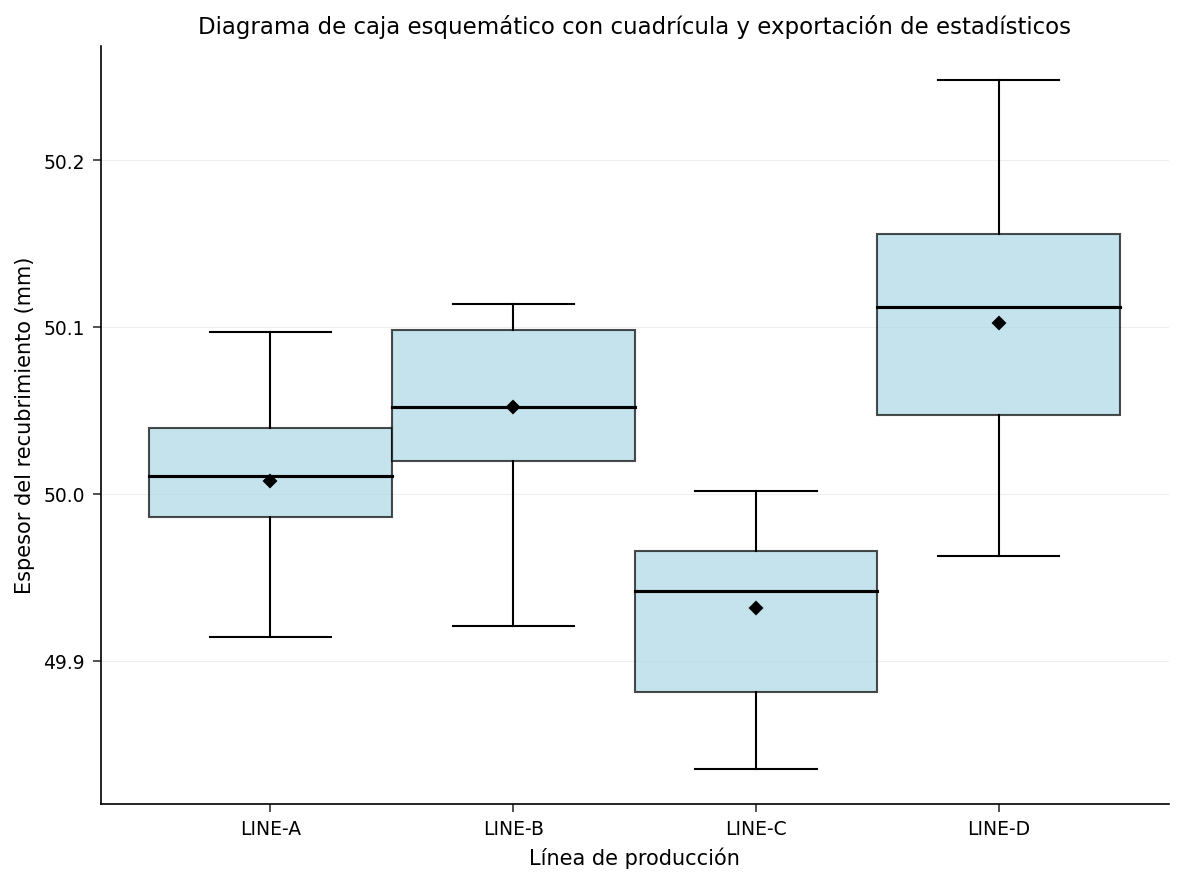

In [5]:
TÍTULO 'Diagrama de caja esquemático con cuadrícula y exportación de estadísticos';
PROCEDIMIENTO boxplot DATOS=ProcessMeas;
   PLOT Thickness*Line / boxstyle=schematic
                         grid
                         outbox=BoxStats;
EJECUTAR;

TÍTULO 'Estadísticos de caja calculados (OUTBOX=)';
PROCEDIMIENTO IMPRIMIR DATOS=BoxStats noobs;
EJECUTAR;

/* Evaluar cada línea frente a la especificación 49.80 / 50.20 mm  */
/* usando los extremos de bigote exportados (THICKNESSL = bigote   */
/* inferior, THICKNESSH = bigote superior).                        */
DATOS SpecCheck;
   ESTABLECER BoxStats;
   LONGITUD Status $40;
   LSL = 49.80;
   USL = 50.20;
   SI THICKNESSH > USL ENTONCES Status = 'Piezas altas superan el USL';
   SINO SI THICKNESSL < LSL ENTONCES Status = 'Piezas bajas por debajo del LSL';
   SINO Status = 'Dentro de especificación';
   MANTENER LINE THICKNESSL THICKNESSH LSL USL Status;
EJECUTAR;

TÍTULO 'Evaluación de límites de especificación por línea';
PROCEDIMIENTO IMPRIMIR DATOS=SpecCheck noobs LABEL;
   ETIQUETA LINE='Línea' THICKNESSL='Bigote inferior'
            THICKNESSH='Bigote superior' Status='Estado';
EJECUTAR;

## Paso 6 — Persistir un historial de monitoreo y volver a trazar a partir de él

En el SPC continuo rara vez se reescanea cada medición bruta. `OUTHISTORY=` escribe una fila de resumen por línea (la misma disposición que consume `HISTORY=`), de modo que los pesados datos brutos pueden archivarse. A continuación exportamos `LineHistory`, lo imprimimos y luego demostramos el ciclo de ida y vuelta alimentándolo directamente a un nuevo `PROC BOXPLOT` mediante `HISTORY=`: exactamente cómo un panel diario reutilizaría estadísticos de subgrupo preagregados.

                                            Exportar historial de subgrupos                                             

                                            Exportar historial de subgrupos

                                                 The BOXPLOT Procedure

Skeletal Plots for Espesor del recubrimiento (mm)

Línea de producción      N          Min           Q1       Median           Q3          Max         Mean      Std Dev
------------------------------------------------------------------------------------------------------------
LINE-A               38        49.91        49.99        50.01        50.04        50.10        50.01         0.04
LINE-B               19        49.92        50.02        50.05        50.10        50.11        50.05         0.05
LINE-C               21        49.84        49.88        49.94        49.97        50.00        49.93         0.05
LINE-D               22        49.96        50.05        50.11        50.16        50.25        50.10     


NOTE: Option TITLE changed to Exportar historial de subgrupos.
NOTE: PROC BOXPLOT data=ProcessMeas

NOTE: Output dataset LINEHISTORY created with 4 observations.
NOTE: ODS plot written: boxplot.spec.json
NOTE: Option TITLE changed to Conjunto de datos de historial resumido (una fila por línea).
NOTE: PROC PRINT data=LineHistory

NOTE: PROC PRINT completed: 4 observations printed, 9 variables
NOTE: Option TITLE changed to Diagrama de caja reconstruido a partir del historial resumido.
NOTE: PROC BOXPLOT history=LineHistory

NOTE: ODS plot written: boxplot.spec.json


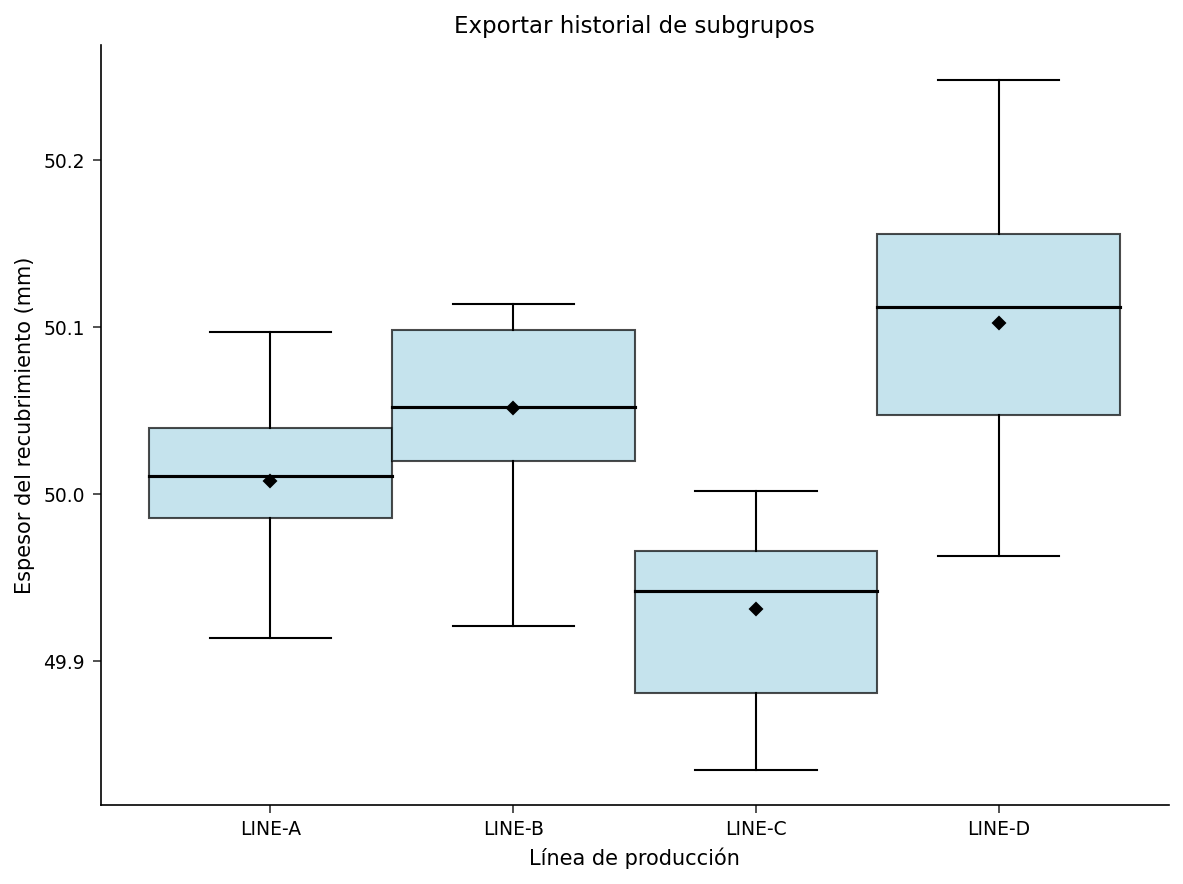

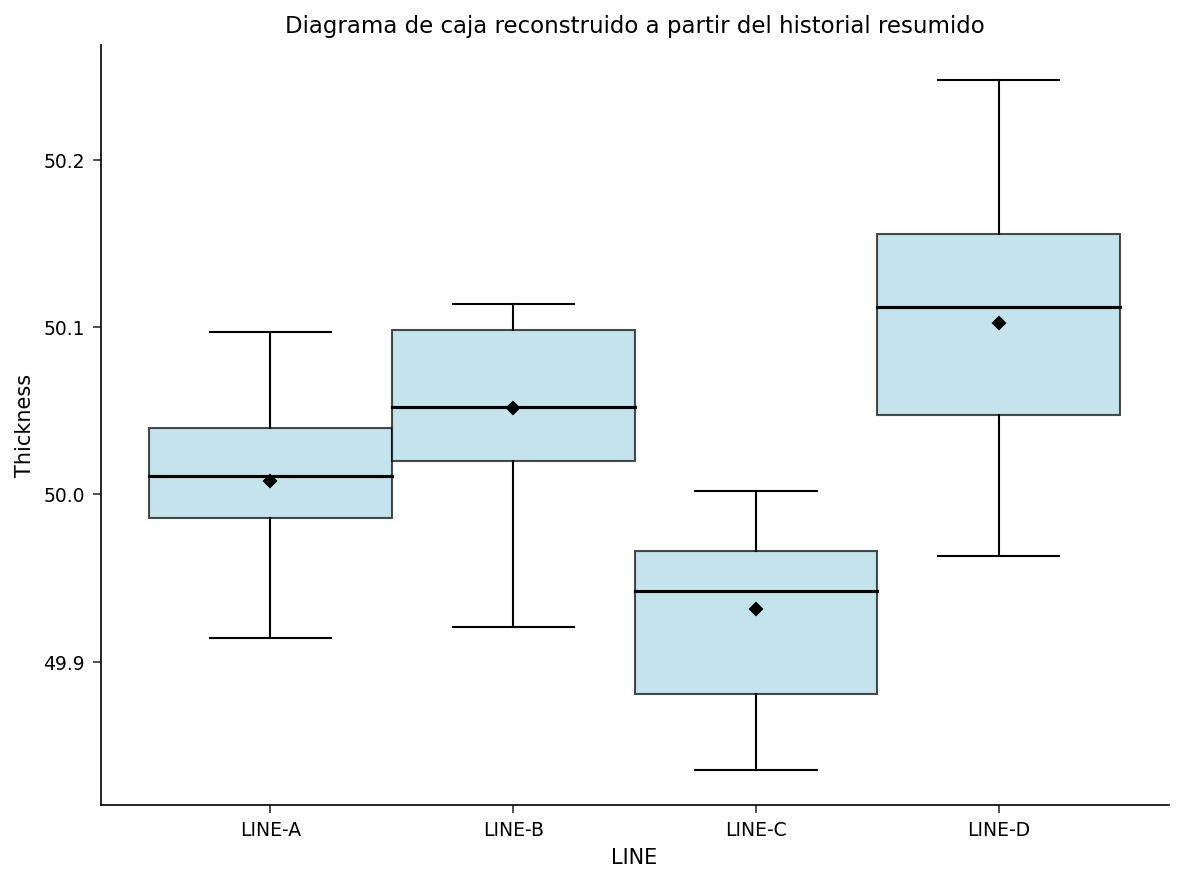

In [6]:
TÍTULO 'Exportar historial de subgrupos';
PROCEDIMIENTO boxplot DATOS=ProcessMeas;
   PLOT Thickness*Line / outhistory=LineHistory;
EJECUTAR;

TÍTULO 'Conjunto de datos de historial resumido (una fila por línea)';
PROCEDIMIENTO IMPRIMIR DATOS=LineHistory noobs;
EJECUTAR;

TÍTULO 'Diagrama de caja reconstruido a partir del historial resumido';
PROCEDIMIENTO boxplot history=LineHistory;
   PLOT Thickness*Line;
EJECUTAR;

## Interpretación de los resultados

Leyendo los diagramas de caja junto con el perfil de `PROC MEANS`, la tabla `OUTBOX=` y la evaluación de límites de especificación:

- **Centrado.** `LINE-A` es la mejor centrada en el objetivo de 50.00 mm (media 50.008 mm, mediana 50.011 mm). `LINE-B` corre ligeramente alta (media 50.052 mm). `LINE-C` corre baja (media 49.932 mm, mediana 49.942 mm), la línea que se desvía hacia el LSL. `LINE-D` corre alta (media 50.102 mm, mediana 50.112 mm), la línea más próxima al USL.
- **Dispersión.** `LINE-D` muestra la caja más ancha y los bigotes más largos: su desviación estándar de 0.080 mm es aproximadamente un 60–80% mayor que la de las otras tres líneas (0.045–0.051 mm), señalándola como la línea menos estable y la mejor candidata para un estudio de reducción de variación. `LINE-A` es la más ajustada (desv. est. 0.045 mm).
- **Colas.** En el estilo esquemático ninguna línea produce un valor atípico fuera de las vallas: cada bigote alcanza el mínimo/máximo real de su línea, de modo que el proceso no está produciendo piezas extremas aisladas. Las diferencias de dispersión provienen del grueso de cada distribución, no de puntos sueltos.
- **Conformidad con la especificación.** Los extremos de bigote de `OUTBOX=`, evaluados frente a 49.80 / 50.20 mm, sitúan a `LINE-A`, `LINE-B` y `LINE-C` completamente **dentro de especificación**. `LINE-D` es la excepción: su bigote superior alcanza **50.248 mm**, más allá del **USL de 50.20 mm**: las piezas altas de `LINE-D` superan la especificación superior.
- **Puesta en operación.** El conjunto de datos `OUTBOX=` da a los auditores los cuartiles, los extremos de bigote, la media y la desviación estándar exactos detrás de la imagen, y `OUTHISTORY=` proporciona un resumen compacto y re-graficable de una fila por línea (Paso 6) para que el gráfico pueda regenerarse de forma programada sin conservar las mediciones brutas: el diagrama de caja reconstruido a partir del resumen es idéntico al trazado a partir de los datos brutos.

**Acciones a tomar:** priorizar `LINE-D` —recentrarla hacia abajo hacia el objetivo y lanzar un estudio de reducción de variación para llevar su bigote superior de vuelta dentro del USL—; empujar `LINE-C` hacia arriba hacia el objetivo antes de que su cola baja alcance el LSL; `LINE-A` y `LINE-B` funcionan de forma aceptable.